### Libraries

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from typing import List

# 5. Wprowadzenie do sieci neuronowych

## Biblioteka PyTorch

PyTorch to biblioteka uczenia maszynowego(szczgólnie głębokiego), podobna do NumPy, jednak z pewnymi różnicami.

Fundamentem biblioteki jest obiekt `torch.Tensor`, który stanowi uogólnienie macierzy do dowolnej liczby wymiarów. Poniższa tabela przedstawia mapowanie popularnych operacji NumPy na ich odpowiedniki w PyTorch:

| Funkcjonalność | NumPy (`np.ndarray`) | PyTorch (`torch.Tensor`) |
| :--- | :--- | :--- |
| **Podstawowy obiekt** | `ndarray` | `Tensor` |
| **Agregacja (suma)** | `A.sum(axis=0)` | `A.sum(dim=0)` |
| **Konkatenacja** | `np.concatenate` | `torch.cat` |
| **Potęgowanie** | `np.power` | `torch.pow` |

PyTorch zastępuje argument `axis` terminem `dim` (skrót od *dimension*).

PyTorch umożliwia bezkosztową konwersję danych pomiędzy strukturami `ndarray` a `Tensor`. Dane często dzielą tę samą przestrzeń w pamięci, co czyni proces bardzo efektywnym.

Konwersja do formatu Tensor:
  ```python
  tensor_data = torch.from_numpy(numpy_array)
  ```

To, co wyróżnia tę bibliotekę na tle standardowych narzędzi matematycznych, to:

1.  **Mechanizm Autograd:** automatycznie wyznacza gradienty, eliminując potrzebę ręcznego wyprowadzania wzorów matematycznych.
2.  **Akceleracja sprzętowa (GPU):** możliwość przeniesienia obliczeń na kartę graficzną sprawia, że trening sieci neuronowych jest nieporównywalnie szybszy niż na procesorze (CPU).

Zaimplementuj w PyTorchu nastepujące funkcje kosztu:

In [ ]:
def mean_squared_error(X: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    ...

def mean_error(X: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    ...


def max_error(X: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    ...


In [ ]:
X_test = torch.tensor([[0.0, 0.0], [3.0, 4.0]])
theta_test = torch.tensor([0.0, 0.0])

assert torch.allclose(mean_squared_error(X_test, theta_test), torch.tensor(12.5)), "Error mean_squared_error"
assert torch.allclose(mean_error(X_test, theta_test), torch.tensor(2.5)), "Error mean_error"
assert torch.allclose(max_error(X_test, theta_test), torch.tensor(5.0)), "Error max_error"

## Optymalizatory


Poniżej zaimplementowana jest klasa bazowa optymalizatora, po której dziedziczyć będą dalsze optymalizatory.

In [ ]:
class Optimizer:
    def __init__(self, initial_params):
        self.params = initial_params

    def step(self):
        raise NotImplementedError()

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.detach_()
                param.grad.zero_()


class GradientDescent(Optimizer):

    def __init__(self, initial_params: List[torch.tensor], learning_rate):
        super().__init__(initial_params)
        self.learning_rate = learning_rate

    @torch.no_grad()
    def step(self):
        for param in self.params:
            param -= self.learning_rate * param.grad

def visualize_optimizer(optim, n_steps, title=None, **params):

    def f(w):
        coeffs = torch.tensor([0.2, 2.0], dtype=torch.float)
        return torch.sum(coeffs * w ** 2)

    w = torch.tensor([-6.0, 2.0], dtype=torch.float, requires_grad=True)

    optimizer = optim([w], **params)

    history = [w.clone().detach().numpy()]

    for i in range(n_steps):
        optimizer.zero_grad()
        loss = f(w)
        loss.backward()
        optimizer.step()
        history.append(w.clone().detach().numpy())

    x = np.linspace(-7.0, 7.0, 200)
    y = np.linspace(-4.0, 4.0, 200)
    X, Y = np.meshgrid(x, y)

    Z = 0.2 * X ** 2 + 2 * Y ** 2

    fig, ax = plt.subplots(figsize=(12, 7))
    cs = ax.contour(X, Y, Z, levels=30, cmap='magma', alpha=0.6)
    ax.clabel(cs, inline=True, fontsize=8)

    h = np.array(history)

    ax.plot(h[:,0], h[:,1], 'o-', color='teal', markersize=3, linewidth=1.5, label="Path")

    ax.plot(h[0,0], h[0,1], 'ro', label="Start")

    if title is not None:
        ax.set_title(title, fontsize=14, pad=15)

    ax.legend()
    ax.grid(True, alpha=0.3)

In [ ]:
visualize_optimizer(GradientDescent, n_steps=20, learning_rate=0.1, title='Too low LR')

In [ ]:
visualize_optimizer(GradientDescent, n_steps=15, learning_rate=0.5, title='Too high LR')

### **Momentum**

Algorytm modyfikuje standardową procedurę spadku gradientu poprzez uwzględnienie kierunku z poprzednich kroków. Pozwala to na "nabranie prędkości" w kierunkach o niskiej zmienności gradientu i tłumienie oscylacji.

Hiperparametry

* **$\gamma$ (Momentum):** Współczynnik pędu (zawsze < 1, typowo 0.9)
* **$\eta$ (Learning Rate):** Współczynnik uczenia (typowe wartości: od 0.001 do 0.01)

Wzory opisujące aktualizację w kroku $t$:

$$\Delta_{t+1} = \gamma \Delta_t + \eta \nabla_\theta J(\theta_t)$$
$$\theta_{t+1} = \theta_t - \Delta_{t+1}$$


 Wektor pędu $v$ ma dokładnie taki sam wymiar jak wektor parametrów $\theta$.



In [ ]:
class Momentum(Optimizer):

    def __init__(self, initial_params, learning_rate, gamma):
        super().__init__(initial_params)

        self.learning_rate = learning_rate
        self.gamma = gamma

        self.deltas = []

        for param in self.params:
            self.deltas.append(torch.zeros_like(param))

    @torch.no_grad()
    def step(self):
        for param, delta in zip(self.params, self.deltas):
            delta *= ...
            delta += ...
            param -= ...

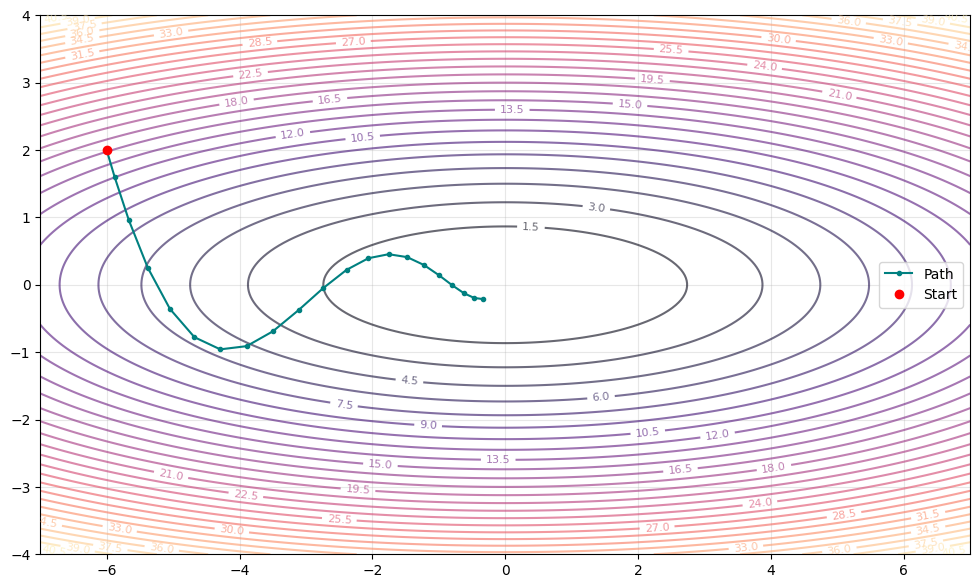

In [ ]:
visualize_optimizer(Momentum, n_steps=20, learning_rate=0.05, gamma=0.8)

### **Adagrad**

Algorytm automatycznie dostosowuje współczynnik uczenia osobno dla każdego parametru. Jest szczególnie efektywny w zadaniach, gdzie dane są rzadkie (sparse), ponieważ zwiększa krok uczenia dla rzadziej występujących cech.

Hiperparametry

* **$\eta$ (Learning Rate):** Współczynnik uczenia (typowe wartości: od **0.001** do **0.01**).
* **$\epsilon$ (Epsilon):** Mała stała dodawana do mianownika w celu uniknięcia dzielenia przez zero (typowo **$10^{-8}$**).

Wzory opisujące aktualizację:

$$G_t = \sum_{i=1}^{t} (\nabla_\theta J(\theta_i))^2$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \odot \nabla_\theta J(\theta_t)$$

Gdzie:
* $G_t$ to suma kwadratów gradientów dla kroków od $1$ do $t$.
* $\odot$ oznacza mnożenie element-wise (po współrzędnych).



In [ ]:
class Adagrad(Optimizer):

    def __init__(self, initial_params, learning_rate, epsilon):
        super().__init__(initial_params)
        self.learning_rate = learning_rate
        self.epsilon = epsilon

        self.G = []

        ...

    @torch.no_grad()
    def step(self):
        ...

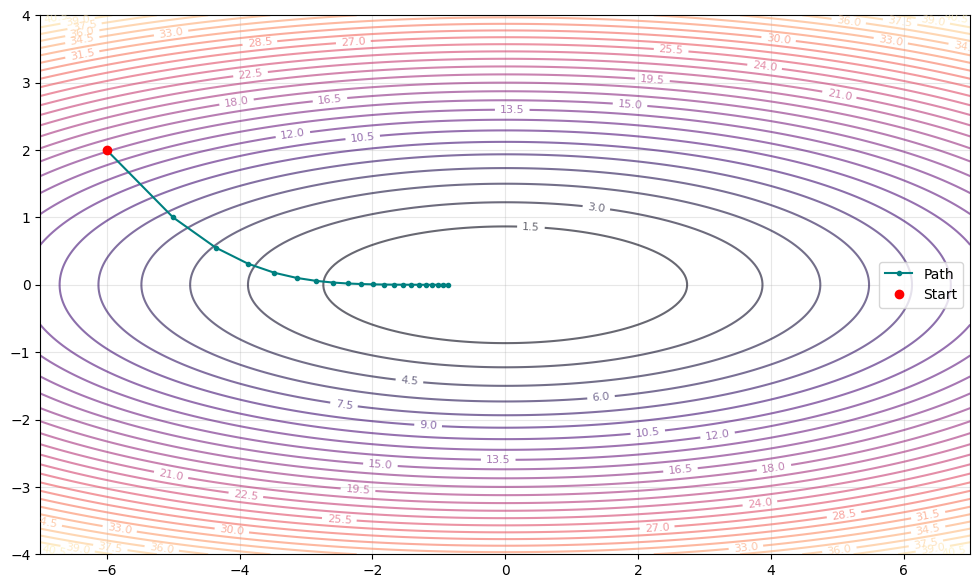

In [ ]:
visualize_optimizer(Adagrad, n_steps=20, learning_rate=1.0, epsilon=1e-8)

### **Adadelta**

Algorytm jest rozwinięciem metody Adagrad, którego celem jest rozwiązanie problemu gwałtownie malejącego współczynnika uczenia. Główną innowacją jest zastąpienie globalnego parametru learning rate średnią kroczącą z kwadratów poprzednich aktualizacji parametrów.

Hiperparametry

* **$\rho$ (Rho):** Współczynnik zanikania średniej kroczącej (typowo **0.9**).
* **$\epsilon$ (Epsilon):** Mała stała dodawana w celu uniknięcia dzielenia przez zero oraz umożliwienia startu uczenia (typowo od **$10^{-8}$** do **$10^{-2}$**).

Wzory opisujące aktualizację:

Akumulacja kwadratów gradientów:
$$H_{t+1} = \rho H_t + (1 - \rho) (\nabla_\theta J(\theta_t))^2$$

Obliczenie poprawki:

$$\Delta_{t+1} = \frac{\sqrt{D_t + \epsilon}}{\sqrt{H_{t+1} + \epsilon}} \odot \nabla_\theta J(\theta_t)$$

Akumulacja kwadratów poprawek :

$$D_{t+1} = \rho D_t + (1 - \rho) \Delta_{t+1}^2$$

Aktualizacja parametrów:
$$\theta_{t+1} = \theta_t + \Delta \theta_{t+1}$$

Wektory $H_0$ oraz $D_0$ mają taki sam wymiar jak wektor parametrów $\theta$.

In [ ]:
class Adadelta(Optimizer):
    def __init__(self, initial_params, gamma, epsilon):
        super().__init__(initial_params)
        self.gamma = gamma
        self.epsilon = epsilon

        self.hist = []
        self.deltas = []
        self.prevs = []


        for param in self.params:
            ...

    @torch.no_grad()
    def step(self):
        for i, (param, h, d) in enumerate(zip(self.params, self.hist, self.deltas)):
            ...


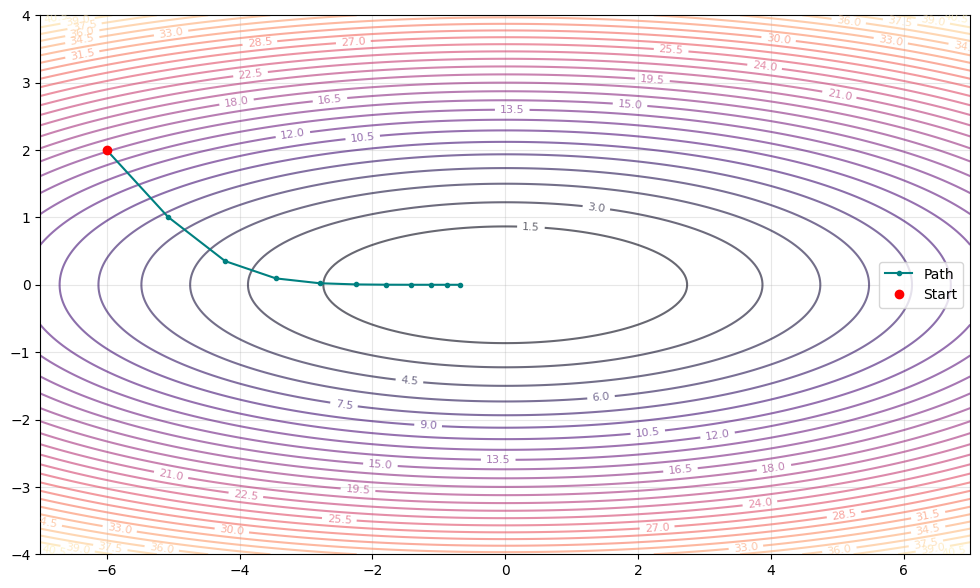

In [ ]:
visualize_optimizer(Adadelta, n_steps=10, gamma=0.9, epsilon=1e-1)

### **Adam**

Algorytm optymalizacji, który oblicza adaptacyjne współczynniki uczenia dla każdego parametru. Przechowuje on średnią kroczącą zarówno gradientów (pierwszy moment), jak i kwadratów gradientów (drugi moment).

Hiperparametry

* **$\eta$ (Learning Rate):** Współczynnik uczenia (typowo **0.001**).
* **$\beta_1$:** Współczynnik średniej kroczącej pierwszego momentu (typowo **0.9**).
* **$\beta_2$:** Współczynnik średniej kroczącej drugiego momentu (typowo **0.999**).
* **$\epsilon$:** Stała zapobiegająca dzieleniu przez zero (typowo **$10^{-8}$**).


Wzory opisujące aktualizację:

Aktualizacja momentów:
   $$m_{t+1} = \beta_1 m_t + (1 - \beta_1) \nabla_\theta J(\theta_t)$$
   $$v_t = \beta_2 v_t + (1 - \beta_2) (\nabla_\theta J(\theta_t))^2$$

Korekta obciążenia (Bias correction):
   $$\hat{m} = \frac{m_{t+1}}{1 - \beta_1^{(t+1)}}$$
   $$\hat{v} = \frac{v_{t+1}}{1 - \beta_2^{(t+1)}}$$

Aktualizacja parametrów:
   $$\theta_{t+1} = \theta_t - {\eta} \frac{\hat{m}}{\sqrt{\hat{v}_t} + \epsilon}$$


Wektory momentów $m_0$ oraz $v_0$ mają taki sam wymiar jak wektor parametrów $\theta$.

In [ ]:
class Adam(Optimizer):

    def __init__(self, initial_params, learning_rate, beta1, beta2, epsilon):
        super().__init__(initial_params)
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon

        ...

    @torch.no_grad()
    def step(self,):
        ...

/tmp/ipykernel_743/2264708541.py:31: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  param -= self.learning_rate * (m_hat / (np.sqrt(v_hat) + self.epsilon))


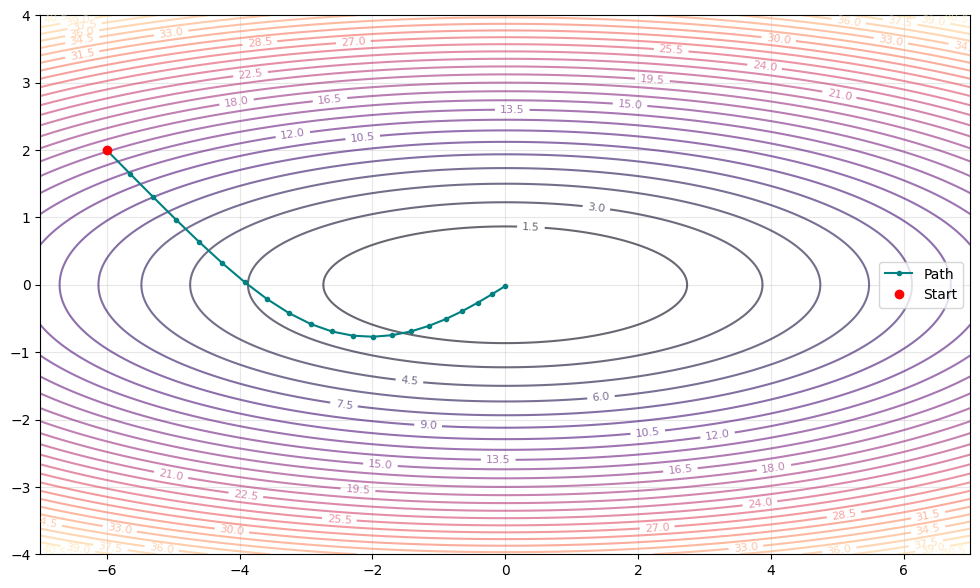

In [ ]:
visualize_optimizer(Adam, n_steps=20, learning_rate=0.35, beta1=0.9, beta2=0.999, epsilon=1e-8)



## Wprowadzenie do sieci neuronowych

Z użyciem [TensorFlow Playground](https://playground.tensorflow.org/) przeprowadź poniższe eksperymenty i opisz uzyskane rezultaty.

Nie należy zmieniać Ratio of training to test data ani Feature'ów wejściowych ($X_1, X_2$, itd.), chyba że polecenie na to wskazuje.

**Zadanie 1.**
Uruchom symulację na domyślnym zbiorze danych (Gaussian) i wykonaj poniższe kroki, aby zaobserwować podstawowe mechanizmy uczenia się sieci.

Polecenia:
1. Rozpocznij trening i zaobserwuj, jak szybko rysowana jest granica decyzyjna.
2. Zmniejsz współczynnik uczenia (**Learning Rate**) o dwa rzędy wielkości i powtórz eksperyment.
3. Zmień funkcję aktywacji z **tanh** na **ReLU** i zaobserwuj różnicę w procesie zbieżności.


Pytania:
1. Jak zmiana Learning Rate wpłynęła na stabilność i czas osiągnięcia zbieżności modelu?
2. Porównując funkcje tanh i ReLU, jakie różnice zauważyłeś w kształcie tworzonej granicy decyzyjnej lub szybkości uczenia?
3. Czy przy tak prostym zadaniu (dane liniowo separowalne) zmiana architektury na głębszą (np. 4-4) przyniosła zauważalną korzyść?

In [ ]:
# ...

**Zadanie 2.** Zbiór danych Circle wymaga od sieci stworzenia nieliniowej granicy decyzyjnej. Przeprowadź poniższe testy, aby zbadać, jak architektura i dobór cech wpływają na wynik.

Załóżmy, że dysponujemy siecią z **jednym neuronem**.

Zadania/Pytania:
1. Ile najmniej oraz jakie konkretnie feature'y wejściowe należy wybrać, aby model osiągnął na zbiorze testowym koszt $Loss < 0.001$?
2. Załóżmy, że na wejściu mamy tylko podstawowe, niezanurzone cechy ($X_1, X_2$). Znajdź najmniejszą pod względem liczby neuronów architekturę sieci, która osiąga na zbiorze testowym koszt $Loss < 0.01$. Podaj jej strukturę lub postaw hipotezę, dlaczego uzyskanie takiego wyniku przy minimalnej liczbie neuronów jest trudne.
3. Spróbuj rozwiązać problem zbioru "Circle" za pomocą dowolnie dużej sieci neuronowej, ale przy użyciu liniowych funkcji aktywacji. Nie zmieniaj domyślnych cech wejściowych ($X_1, X_2$).Czy udało się osiągnąć zadowalający wynik? Sformułuj krótką hipotezę wyjaśniającą, dlaczego sieć liniowa (niezależnie od głębokości) zachowuje się w tym przypadku w określony sposób.

In [ ]:
# ...

**Zadanie 2.** Zbiór Spiral jest najbardziej wymagającym wyzwaniem w TensorFlow Playground. Wymaga on złożonej architektury i starannej regularyzacji, aby granica decyzyjna poprawnie odzwierciedlała kręty kształt danych.

Zadania/Pytania:
1. Twoim zadaniem jest osiągnięcie **stabilnego** kosztu testowego $Loss < 0.1$. Podaj wykorzystaną architekturę, rodzaj aktywacji, regularyzację oraz learning rate.
2. Co wizualnie odróżnia rozwiązania, które dobrze generalizują, od tych, które uległy zjawisku overfittingu (przeuczenia)? Zwróć uwagę na kształt kolorowych obszarów tam, gdzie nie ma punktów danych.

In [ ]:
# ...